# AI Classification of thesis title categories into superordinate cateogires


In [1]:
import os
import pandas as pd
from IPython.display import display, Markdown
from tqdm.auto import tqdm # makes pretty progress bars
tqdm.pandas()              # makes pretty progress bars in pandas with progress_apply()

# this should be familiar!
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
## setting up API key

## importing data
# WITH THIS
data_dir = "https://docs.google.com/spreadsheets/d/13I6-BkzqQfrkF8LdA1_58UU4KaZD3S1EfnoYXUrhjsc/edit?gid=1887238280#gid=1887238280"
# see the Elon data https://docs.google.com/spreadsheets/d/1VNJs_YrG66g30JOc8VpzSJNACPw45whZXn28WDwPaWE/edit?gid=380065761#gid=380065761
## if you're reusing this notebook for your own dataset, replace this with a link to your data
## you will probably have to replace both the 1VNJs thing and 380065761 with the numbers from your Google Sheet
macro_categories = pd.read_csv('https://docs.google.com/spreadsheets/d/13I6-BkzqQfrkF8LdA1_58UU4KaZD3S1EfnoYXUrhjsc/export?format=csv&gid=1887238280')



##
## take a random sample to test our prompts against
text_column_name = "category" # change this to match your own dataset

macro_categories.set_index("Title", inplace=True)

 
SIZE_OF_SAMPLE_FOR_HANDCODING = 50

data_sample = macro_categories.sample(n=SIZE_OF_SAMPLE_FOR_HANDCODING, random_state=613)

data_sample = data_sample.copy() # avoid annoying warnings!

In [3]:
data_sample.head()

,category
Title,
An economic study of the port of Cochin _its trade traffic and working_,business-cochin port
A Study On Deen Dayal Upadyaya Grameen Kaushalya Yojana In Ernakulam District,socioeconomics
Zooplankton studies in the Cochin environs,ecology/aquatic/scientific
Secondary Prevention of Coronary Artery Diseases a Prospective Cohort Study to Assess Trends and Predictors of Compliance from Ernakulam Kerala,health
Factors responsible for total literacy a case study of Ernakulam district,higher education


In [4]:

## setting up our connection to an API client for an AI provider
# for Lede, we're using OpenRouter, which connects to most providers
# but I've provided code for connect to other providers directly, if you want to do that in real life

USE_OPENROUTER=True

from anthropic import Anthropic

if USE_OPENROUTER:
  from openrouter import OpenRouter
else:
  from openai import OpenAI
  from mistralai.client import Mistral

if USE_OPENROUTER:
  openrouter_client = OpenRouter(api_key=os.environ.get("OPENROUTER_API_KEY_LEDE"))
else:
  openai_client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY_LEDE"))
  mistral_client = Mistral(api_key=os.environ.get("MISTRAL_API_KEY_LEDE"))
anthropic_client = Anthropic(api_key=os.environ.get("ANTHROPIC_API_KEY_LEDE"),) # intentionally created outside of the if; we'll use anthropic_client to count tokens (even if we're using openrouter)


A basic format for a prompt is below. Using the web version of ChatGPT (chatgpt.com) tweak this until you're pretty consistently getting reasonable results.

In [5]:
## prompt
## start with the one YOU tried in the LLM web interface
## don't worry, we'll adjust it later.
## Jeremy's is at the very bottom, if you need to reference it, but please come
##   up with your own.


# Be sure to list the categories (defined below!) with the magic phrase {categories}
prompt_base = """

Read this category of academic PhD thesis titles and tell me which macro-category best describes
it, choosing from just these options: {categories}. Return only the macro-cateogry name,
nothing else.


Here is the category: {title_category}

"""

from enum import Enum, IntEnum

# force the AI to ONLY guess fromn the options we ask you.
# you can change these names! (and perhaps should!)
# - the AI sees the _value_, not the key (it sees "broader_political_issues_except_us_election", not "other_politics")
# - the key is just for you -- a shorthand
# - some AIs have trouble with complicated names, so it's better to stick to lowercase, no special characters
#     (as of early June 2026 -- maybe this will be fixed)
class ThesisMacroCategories(str, Enum):
    science = "Science and Environment"
    industry = "Industry and Economy"
    health = "Health, Society and Wellbeing"
    education = "Education"
    art = "Art and Cultural Memory"


# for convenience, make a column in our dataframes with the prompt for each item
data_sample_prompt_column = data_sample.apply(lambda row: prompt_base.format(
    title_category=row[text_column_name],
    categories=", ".join(['"{}"'.format(opt.value) for opt in ThesisMacroCategories])
), axis="columns")
full_data_prompt_column = macro_categories.apply(lambda row: prompt_base.format(
    title_category=row[text_column_name],
    categories=", ".join(['"{}"'.format(opt.value) for opt in ThesisMacroCategories])
), axis="columns")

In [6]:
print(data_sample_prompt_column.iloc[0]) # this is the prompt



Read this category of academic PhD thesis titles and tell me which macro-category best describes
it, choosing from just these options: "Science and Environment", "Industry and Economy", "Health, Society and Wellbeing", "Education", "Art and Cultural Memory". Return only the macro-cateogry name,
nothing else.


Here is the category: business-cochin port




In [7]:
## cost estimation

from strip_tags import strip_tags
import tiktoken
def count_tokens(model, text):
  if "claude" in model and os.environ.get("ANTHROPIC_API_KEY_LEDE"):
    return anthropic_client.messages.count_tokens(model=model, messages=[{"content": text, "role": "user"}])
  elif "gpt" in model:
    encoding = tiktoken.encoding_for_model('gpt-4o') # most modern models use the same tokenizer
    tokens = encoding.encode(text)
    return len(tokens)
  else:
    return count_tokens("gpt-4o", text) # for estimation purposes, pretend mistral is chatgpt...

INPUT_TOKEN_COSTS = {
    "gpt-5-mini": 0.40 / 1_000_000,  # https://openai.com/api/pricing/
    "gpt-5.4-mini": 0.75 / 1_000_000,
    "gpt-5.4": 2.5 / 1_000_000,
    "gpt-5.5": 5 / 1_000_000,
    "gpt-5.4-nano": 0.2 / 1_000_000,
    "mistral-medium-latest": 1.5 / 1_000_000, # https://mistral.ai/pricing#api-pricing
    "mistral-large-latest":  0.5 / 1_000_000,  # No, I don't know why medium is more expensive than large.
    "claude-4.5-haiku": 1 / 1_000_000,
    "claude-4.6-sonnet": 3 / 1_000_000
}
# ignores outputs, since the model will output fairly little text

def estimate_cost(model, token_count):
    return token_count * INPUT_TOKEN_COSTS[model]


In [8]:

# IMPORTANT: let's pick a model to use
# it's got to be listed in INPUT_TOKEN_COSTS up above

DEFAULT_MODEL_TO_USE = 'gpt-5.4-nano'
display(Markdown("Pick a model to use: \n" + "\n - ".join(list(INPUT_TOKEN_COSTS.keys()))))
MODEL_TO_USE = None

while MODEL_TO_USE not in INPUT_TOKEN_COSTS.keys():
  MODEL_TO_USE = input(f"type a model name (press enter for default: {DEFAULT_MODEL_TO_USE}): ").strip()
  if MODEL_TO_USE == "":
    MODEL_TO_USE = DEFAULT_MODEL_TO_USE


Pick a model to use: 
gpt-5-mini
 - gpt-5.4-mini
 - gpt-5.4
 - gpt-5.5
 - gpt-5.4-nano
 - mistral-medium-latest
 - mistral-large-latest
 - claude-4.5-haiku
 - claude-4.6-sonnet

type a model name (press enter for default: gpt-5.4-nano):  claude-4.6-sonnet


The code blocks below will let you estimate costs. If it's too pricey with `gpt-5.4`, consider a cheaper model.

In [9]:
## cost estimation sample

count_tokens_for_our_model = lambda text: count_tokens(MODEL_TO_USE, text)

token_count_sample = count_tokens_for_our_model("SAMPLE RESPONSE SAMPLE RESPONSE".join(data_sample_prompt_column))
"Sample would cost: ${:.2f}".format(estimate_cost(MODEL_TO_USE, token_count_sample))

'Sample would cost: $0.01'

In [10]:
## cost estimation for full dataset
token_count_full = count_tokens_for_our_model("SAMPLE RESPONSE SAMPLE RESPONSE".join(full_data_prompt_column))
"Full dataset would cost: ${:.2f}".format(estimate_cost(MODEL_TO_USE, token_count_full))

'Full dataset would cost: $0.09'

Below is the actual call to the OpenAI API (or your chosen LLM). Run your sample on the same model you want to use for your real data.

**BUT FIRST**: adjust the categories below to match what you defined in your prompt.

In [11]:

## a lot of boilerplate for sending our prompt + tweet to the model and getting an answer
from pydantic import BaseModel


class ThesisMacroValidOptions(BaseModel):
  classification: ThesisMacroCategories

SYSTEM_PROMPT = "You are a helpful assistant"

# def anthropic_classify(prompt_including_tweet):
#     # put our prompt into the blob that OpenAI expects
#     message = anthropic_client.messages.parse(
#         max_tokens=1024,
#         # system=SYSTEM_PROMPT, # causes trouble with structured outputs, oddly
#         messages = [
#             {
#                 "role": "user",
#                 "content": prompt_including_tweet,
#             }
#         ],
#         model=MODEL_TO_USE,
#         output_format=ThesisMacroValidOptions
#     )
#     return message.content[0].parsed_output.classification.value if message.content[0].parsed_output else None

# def mistral_classify(prompt_including_tweet):
#     # put our prompt into the blob that OpenAI expects
#     chat_response = mistral_client.chat.parse(
#       model=MODEL_TO_USE,
#       messages=[
#           {
#               "role": "system",
#               "content": SYSTEM_PROMPT
#           },
#           {
#               "role": "user",
#               "content": prompt_including_tweet
#           },
#       ],
#       response_format=MuskTweetValidOptions,
#       max_tokens=256,
#       temperature=0
#     )
#     return chat_response.choices[0].message.parsed.classification.value if chat_response.choices[0].message.parsed else None

# def chatgpt_classify(prompt_including_tweet):
#     # put our prompt into the blob that OpenAI expects
#     messages = [
#         {
#             "role": "system",
#             "content": SYSTEM_PROMPT
#         },
#         {
#             "role": "user",
#             "content": prompt_including_tweet,
#         }
#     ]
#     chat_completion = openai_client.responses.parse(
#         input=messages,
#         model=MODEL_TO_USE,
#         text_format=MuskTweetValidOptions,
#     )

#     # get the answer out of the blob that OpenAI returns.
#     resp = chat_completion.output_parsed.classification.value if chat_completion.output_parsed else None
#     return resp

openrouter_model_names = {
    "gpt-5-mini": "openai/gpt-5-mini",
    "gpt-5.4-mini": "openai/gpt-5.4-mini",
    "gpt-5.4": "openai/gpt-5.4",
    "gpt-5.5": "openai/gpt-5.5",
    "gpt-5.4-nano": "openai/gpt-5.4-nano",
    "mistral-medium-latest": "mistralai/mistral-medium-3-5",
    "mistral-large-latest": "mistralai/mistral-large-2512",
    "claude-4.5-haiku": "anthropic/claude-4.5-haiku",
    "claude-4.6-sonnet": "anthropic/claude-4.6-sonnet"
}
def openrouter_classify(thesis_prompt):
    response = openrouter_client.chat.send(
        model=openrouter_model_names[MODEL_TO_USE],
        messages=[
            {"role": "user", "content": thesis_prompt}
        ],
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "thesis_classification",
                "strict": True,
                "schema": ThesisMacroValidOptions.model_json_schema(),
            },
        },
    )
    return  ThesisMacroValidOptions.model_validate_json(
        response.choices[0].message.content
    ).classification.value

def classify(thesis_prompt):
  "A wrapper that takes your academic prompt and runs it through the AI"
  if USE_OPENROUTER:
    return openrouter_classify(thesis_prompt)
  else:
    if "mistral" in MODEL_TO_USE == "mistral-medium-latest":
      return mistral_classify(thesis_prompt)
    elif "claude" in MODEL_TO_USE:
      return anthropic_classify(thesis_prompt)
    elif "gpt" in MODEL_TO_USE:
      return chatgpt_classify(thesis_prompt)
    else:
      raise ValueError("Unknown model")

In [13]:
# ask ChatGPT about each and every tweet IN THE SAMPLE, using the prompt we made above
data_sample["ai_guess"] = data_sample_prompt_column.progress_apply(classify)

  0%|          | 0/50 [00:00<?, ?it/s]

In [14]:
display(Markdown("## Here are a few results. How good did we do?"))
with pd.option_context("display.max_colwidth", 500):
  display(
      data_sample[[text_column_name, "ai_guess"]].head(5)
  )

## Here are a few results. How good did we do?

,category,ai_guess
Title,,
An economic study of the port of Cochin _its trade traffic and working_,business-cochin port,Industry and Economy
A Study On Deen Dayal Upadyaya Grameen Kaushalya Yojana In Ernakulam District,socioeconomics,Industry and Economy
Zooplankton studies in the Cochin environs,ecology/aquatic/scientific,Science and Environment
Secondary Prevention of Coronary Artery Diseases a Prospective Cohort Study to Assess Trends and Predictors of Compliance from Ernakulam Kerala,health,"Health, Society and Wellbeing"
Factors responsible for total literacy a case study of Ernakulam district,higher education,Education


# Analysis of Handcoded CSV

In [15]:
data_sample.columns

Index(['category', 'ai_guess'], dtype='str')

In [16]:
# This code will adds a new blank 'groundtruth' column, then exports it to CSV, and downloads it.
# i removed index = False as I have used the Title column as index. In future, keep a separate 
#numberical column for index like serial number. 

data_sample.to_csv('ThesisCategorisation_Handcoded_sample.csv')

Now open that CSV in Google Sheets or Excel, and fill in the `groundtruth` column with the right answer.

Then upload it back here (by clicking the folder icon to the left), or, if you're using a Jupyter Notebook, put it in the same folder as your notebook. **Important** name the file `handcoded.csv`.

In [17]:
handcoded = pd.read_csv("ThesisCategorisation_Handcoded_sample.csv").set_index("Title") # for some countries add `, delimiter=";"`
if "groundtruth" not in handcoded.columns:
  print("uh oh, your handcoded.csv doesn't have a column named groundtruth")
  assert "groundtruth" in handcoded.columns
if handcoded.groundtruth.isna().any() or (handcoded.groundtruth == '').any():
  print("uh oh, there are some blanks in your handcoded.csv's groundtruth column. go fix that!")

# if the ai_guess column got lost in the process... we'll grab it again
if "ai_guess" not in handcoded:
  handcoded = handcoded.merge(data_sample[["ai_guess"]], right_index=True, left_index=True)

In [18]:
from sklearn.metrics import accuracy_score
display(Markdown("Accuracy score: {:.1%}. Is that good?".format(
    accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])
)))


Accuracy score: 100.0%. Is that good?

# Stop here!
## Different ways of measuring accuracy


  This is a confusion matrix, that displays the count of each combo of possible answers and predictions.

  What conclusion do we draw from this?

  What kinds of errors are most common?
  

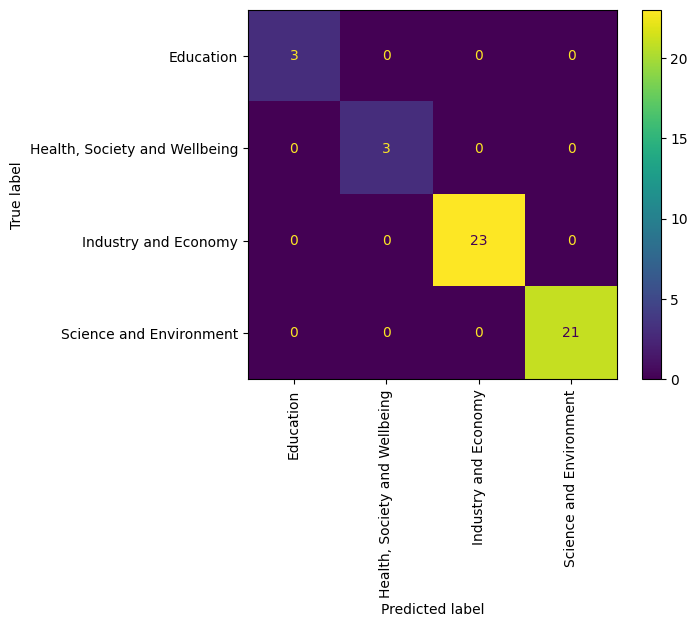

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(handcoded["groundtruth"], handcoded["ai_guess"],  xticks_rotation="vertical");
display(Markdown("""
  This is a confusion matrix, that displays the count of each combo of possible answers and predictions.

  What conclusion do we draw from this?

  What kinds of errors are most common?
  """))

In [20]:
# calculate baseline
accuracy = accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])
most_common_answer = handcoded.groupby("groundtruth").count().idxmax().ai_guess
baseline = accuracy_score(handcoded["groundtruth"], [most_common_answer] * len(handcoded["ai_guess"]))


display(Markdown("""is {:.1%} good? Well, let's measure *model skill*. Is the AI _doing anything_?

Let's compare it to the stupidest model possible, that just guesses the most common class ({}) for all outputs. That **baseline** is {:.1%}.

How does {:.1%} compare to {:.1%}?
""".format(
    accuracy,
    most_common_answer,
    baseline,
    accuracy,
    baseline
)))

is 100.0% good? Well, let's measure *model skill*. Is the AI _doing anything_?

Let's compare it to the stupidest model possible, that just guesses the most common class (Industry and Economy) for all outputs. That **baseline** is 46.0%.

How does 100.0% compare to 46.0%?


In [21]:
if accuracy <= baseline:
  new_baseline = accuracy_score(handcoded["groundtruth"], [most_common_answer] * len(handcoded["2-way_category_ai"]))

  display(Markdown("""
    The model is doing worse than (or maybe even with) the baseline.

    But that comparison treats false-positives and false-negatives as equally bad. That might not be right for your problem. For the insults problem,
    all we want to do is shrink the haystack. A baseline that guesses nothing is an insult (as our baseline does) is useless to us. The real
    baseline (reading all of Trump's tweets to find place insults) would be guessing the insult class for everything. That baseline gets {:.1%} --
    way worse than {}. Phew.

    This makes intuitive sense. An AI classification that shrinks the haystack, with a mixture of false-positives and true-positives for us to look at
    is actually really helpful.
  """.format(
      new_baseline,
      accuracy
  )))
else:
  display(Markdown("""
    The model is doing better than baseline.

But maybe we can do even better. Look at the model's mistakes below, adjust the prompt, and see if the accuracy score (or your chosen metric) goes up.
  """.strip()))

with pd.option_context("display.max_colwidth", 500):
  display(
      handcoded[handcoded["ai_guess"] != handcoded["groundtruth"]][[text_column_name, "groundtruth", "ai_guess"]]
  )

The model is doing better than baseline.

But maybe we can do even better. Look at the model's mistakes below, adjust the prompt, and see if the accuracy score (or your chosen metric) goes up.

,category,groundtruth,ai_guess
Title,,,


#### Suppose we only care about one topic.

Maybe your editor decides that we don't care about politics anymore. Just whether Elon's tweets are about his companies. Now, we just have a true-false classification problem.

In [22]:
ThesisMacroCategories.science.value

'Science and Environment'


  This is a confusion matrix, that displays the count of each combo of possible answers and predictions.

  What conclusion do we draw from this?

  What kinds of errors are most common?
  

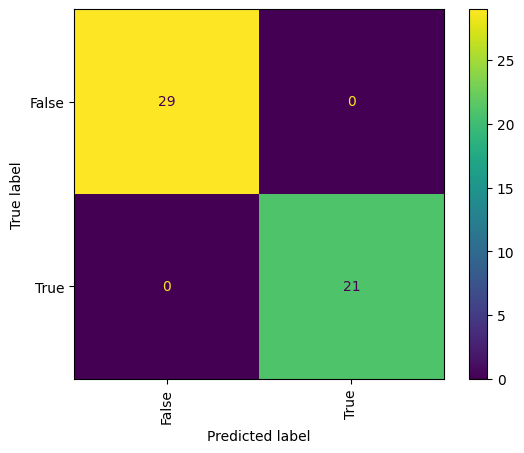

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(handcoded["groundtruth"] == ThesisMacroCategories.science.value, handcoded["ai_guess"] == ThesisMacroCategories.science.value,  xticks_rotation="vertical");
display(Markdown("""
  This is a confusion matrix, that displays the count of each combo of possible answers and predictions.

  What conclusion do we draw from this?

  What kinds of errors are most common?
  """))

The rate of false positives is how many non-science titles have been mistakenly classified under "Science and Environment".

The rate of false negatives is how many science titles the AI ought to have classified under "Science and Environment".

The inverse of the false positive rate is the true positive rate, or **precision**.

The inverse of the false negative rate is the true negative rate. That's **recall**.

    science = "Science and Environment"
    industry = "Industry and Economy"
    health = "Health, Society and Wellbeing"
    education = "Education"
    art = "Art and Cultural Memory"


# Checking precision and Recall scores

In [24]:

from sklearn.metrics import precision_score, recall_score
display(Markdown("Precision score: {:.1%}. Is that good?".format(
    precision_score(handcoded["groundtruth"] == ThesisMacroCategories.science.value, handcoded["ai_guess"] == ThesisMacroCategories.science.value)
)))


from sklearn.metrics import precision_score, recall_score
display(Markdown("Recall score: {:.1%}. Is that good?".format(
    recall_score(handcoded["groundtruth"] == ThesisMacroCategories.science.value, handcoded["ai_guess"] == ThesisMacroCategories.science.value)
)))


Precision score: 100.0%. Is that good?

Recall score: 100.0%. Is that good?

Which do we care about more? Precision or recall? (You tell me!)

These concepts (accuracy, model skill, precision and recall) might be what you'd put in your methodology to prove that your AI was reliable enough. Can you think of situations where you'd use one or another?

We're going to go back in Powerpoint to discuss:

- What kind of accuracy (or precision, or recall, or model skill) is good enough
- How to improve your prompts

## Try a new prompt

And we will see if it does better or worse.

To start out with, try one of these:

- cajoling the model to do a better job

- giving it some examples, based on the errors we saw above

In [ ]:
#USE THIS STEP ONLY IF THE ACCURACY RATE IS REALLY BAD. IF THE CONFUSION MATRIX IS HORRIBLE. 

# new_prompt_base = """
# Read this category of academic PhD thesis titles and tell me which macro-category best describes
# it, choosing from just these options: {categories}. Return only the macro-cateogry name,
# nothing else.



# Thesis categories include categories like Science and Environment", "Industry and Economy

# You are an expert librarian classifying academic theses. 

# Here is the category: {title_category}

# """
#  TO CLASSIFY SAMPLE WITH NEW PROMPT AND CHECK COST for sample, USE THIS: 
# data_sample_new_prompt_column = handcoded.apply(lambda row: new_prompt_base.format(
#     tweet_text=row[text_column_name],
#     categories=", ".join(['"{}"'.format(opt.value) for opt in ThesisMacroCategories])
# ), axis="columns")
# token_count_sample = count_tokens_for_our_model("SAMPLE RESPONSE SAMPLE RESPONSE".join(data_sample_new_prompt_column))
# "Sample would cost: ${:.2f}".format(estimate_cost(MODEL_TO_USE, token_count_sample))

#TO CLASSIFY full dataset WITH NEW PROMPT AND CHECK COST for full dataset, USE THE FOLLOWING CODE:
# full_data_prompt_column = macro_categories.apply(lambda row: prompt_base.format(
#     title_category=row[text_column_name],
#     categories=", ".join(['"{}"'.format(opt.value) for opt in ThesisMacroCategories])
# ), axis="columns")
#token_count_full = count_tokens_for_our_model("SAMPLE RESPONSE SAMPLE RESPONSE".join(full_data_prompt_column))
#"Full dataset would cost: ${:.2f}".format(estimate_cost(MODEL_TO_USE, token_count_full))

In [ ]:
#handcoded["new_ai_guess"] = data_sample_new_prompt_column.progress_apply(classify)

In [ ]:
#accuracy = accuracy_score(handcoded["groundtruth"], handcoded["new_ai_guess"])
#original_prompt_accuracy = accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])

In [ ]:
#display(Markdown("""
  #Your new prompt got an accuracy rate of {:.0%}. Is that better than {:.0%}?

 # Should we be using a different metric? (You tell me!)

  #Keep trying new stuff until it's good enough (whatever that means!) or you get bored.

  #Then you can classify the whole dataset.
#""".format(accuracy, original_prompt_accuracy)))

## Doing the whole thing

Once we're ready, and we think we've accounted for most of the mistakes, we're ready to classify the WHOLE THING.

In [ ]:
# since running the AI over the whole dataset might cost a real amount of money
# this is just an extra check to make sure you want to do it.
# just hit enter (or type anything) to continue
# hit stop (to the left of this cell) to stop
#safety_warning = input("Are you sure you want the AI model to classify your full dataset? This will cost money! If sure, type 'yes'")

In [25]:
full_data_prompt_column = macro_categories.apply(lambda row: prompt_base.format(
    title_category=row[text_column_name],
    categories=", ".join(['"{}"'.format(opt.value) for opt in ThesisMacroCategories])
), axis="columns")

In [29]:
macro_categories["ai_guess"] = full_data_prompt_column.progress_apply(classify)

  0%|          | 0/347 [00:00<?, ?it/s]

In [ ]:
## creating response generator -- full dataset

# we're using the most recent "new prompt"

#full_data_prompt_column = new_prompt_base + data_full[text_column_name]

In [30]:
macro_categories.to_csv('ThesisCategorisation_Full_Results.csv')
